# CS412 Machine Learning

## Homework: Text Classification and Word Embeddings

**Total: 100 points**

This notebook has two questions:

- **Question 1: Word Embeddings with Pre-trained GloVe** - 50 points
- **Question 2: Sentiment Classification with Multinomial Naive Bayes** - 50 points

### Important rule
Each task must be completed in its **respective code cell**. For example, the work for **Cell 1.2** must appear in the code cell labeled **Cell 1.2**. Do not merge multiple tasks into one cell.

Before submission, run all cells and keep all outputs visible in the notebook.

## General Imports

Run this cell before starting the assignment. You may add small utility imports here if needed, but the graded task code should remain inside the corresponding task cells.

In [1]:
# If gensim is not installed, uncomment and run the following line:
!pip install gensim

import re
import string
import zipfile
from io import BytesIO
from urllib.request import urlopen, Request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.manifold import TSNE

# Question 1 - Word Embeddings with Pre-trained GloVe

**50 points total**

In this question, you will use pre-trained GloVe word embeddings. You will load a selected vocabulary, compute cosine similarities, find nearest neighbors, solve simple analogies, and visualize selected embeddings using t-SNE.

## Cell 1.1 - Load GloVe Embeddings

**10 points**

**Goal:** Load `glove-wiki-gigaword-50` using `gensim.downloader`, create a `word_to_vec` dictionary for the selected words, and print basic information about the embeddings.

In [2]:
# Cell 1.1 - Load GloVe Embeddings

import gensim.downloader as api

selected_words = [
    # people / gender / royalty
    "king", "queen", "man", "woman", "boy", "girl",
    "prince", "princess", "actor", "actress",

    # vehicles
    "car", "automobile", "truck", "bus", "train", "bicycle", "road",

    # animals
    "dog", "cat", "puppy", "kitten", "lion", "tiger",

    # sentiment words
    "good", "great", "excellent", "amazing", "fun", "enjoyable",
    "bad", "awful", "terrible", "boring", "dull", "poor",

    # food
    "pizza", "burger", "sushi", "pasta", "cake", "coffee", "banana",

    # movie-related words
    "movie", "film", "cinema", "story", "plot", "soundtrack",

    # countries and capitals
    "france", "paris", "italy", "rome", "turkey", "ankara",
    "japan", "tokyo", "germany", "berlin"
]

# TODO 1: Load the GloVe model using api.load("glove-wiki-gigaword-50").
glove = api.load("glove-wiki-gigaword-50")

# TODO 2: Create a dictionary word_to_vec that maps each selected word to its embedding vector.
word_to_vec = {}

for word in selected_words:
    if word in glove:
        word_to_vec[word] = glove[word]

# TODO 3: Print the number of selected words loaded.
print("Number of selected words loaded:", len(word_to_vec))
# TODO 4: Print the embedding dimension.
print("Embedding dimension:", list(word_to_vec.values())[0].shape[0])
# TODO 5: Print the first 10 selected words that were loaded.
print("First 10 selected words loaded:", list(word_to_vec.keys())[:10])

Number of selected words loaded: 58
Embedding dimension: 50
First 10 selected words loaded: ['king', 'queen', 'man', 'woman', 'boy', 'girl', 'prince', 'princess', 'actor', 'actress']


## Cell 1.2 - Implement Cosine Similarity

**10 points**

**Goal:** Implement cosine similarity manually using NumPy and compare several word pairs.

In [3]:
# Cell 1.2 - Implement Cosine Similarity

def cosine_similarity(vec1, vec2):
    """
    Compute cosine similarity between two vectors.

    cosine(a, b) = (a dot b) / (||a|| ||b||)
    """
    # TODO: Convert inputs to NumPy arrays.
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)
    # TODO: Compute the denominator using vector norms.
    denominator = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    # TODO: Return 0.0 if the denominator is zero.
    if denominator == 0:
      return 0.0

    # TODO: Return the cosine similarity as a float.
    return float(np.dot(vec1, vec2) / denominator)
    pass


word_pairs = [
    ("king", "queen"),
    ("man", "woman"),
    ("car", "automobile"),
    ("car", "banana"),
    ("good", "excellent"),
    ("good", "terrible"),
]

# TODO: Compute and print the cosine similarity for each pair above.
for word1, word2 in word_pairs:
    similarity = cosine_similarity(word_to_vec[word1], word_to_vec[word2])
    print(f"Cosine similarity between '{word1}' and '{word2}': {similarity:.4f}")

Cosine similarity between 'king' and 'queen': 0.7839
Cosine similarity between 'man' and 'woman': 0.8860
Cosine similarity between 'car' and 'automobile': 0.6956
Cosine similarity between 'car' and 'banana': 0.2190
Cosine similarity between 'good' and 'excellent': 0.8062
Cosine similarity between 'good' and 'terrible': 0.5951


## Cell 1.3 - Find Nearest Neighbors

**10 points**

**Goal:** Implement a nearest-neighbor function that returns the most similar selected words to a query word using cosine similarity.

In [4]:
# Cell 1.3 - Find Nearest Neighbors

def nearest_neighbors(word, k=5):
    """
    Return the k nearest words to the query word using cosine similarity.
    Search is restricted to the selected vocabulary in word_to_vec.
    """
    # TODO: Check that the query word exists in word_to_vec.
    if word not in word_to_vec:
      print(f"'{word}' is not in word_to_vec.")
      return []

    similarities = []
    # TODO: Compute cosine similarity between the query word and every other word.
    for other_word, other_vec in word_to_vec.items():
        # Exclude the query word itself
        if other_word != word:
            similarity = cosine_similarity(word_to_vec[word], other_vec)
            similarities.append((other_word, similarity))
    # TODO: Sort by similarity in descending order.
    similarities = sorted(similarities, key=lambda x: x[1], reverse=True)
    # TODO: Return the top-k results.
    return similarities[:k]
    pass


test_words = ["king", "car", "good", "movie", "dog"]

# TODO: Print the 5 nearest neighbors for each word in test_words.
for word in test_words:
    print(f"\nNearest neighbors for '{word}':")
    neighbors = nearest_neighbors(word, k=5)

    for neighbor, similarity in neighbors:
        print(f"{neighbor}: {similarity:.4f}")


Nearest neighbors for 'king':
prince: 0.8236
queen: 0.7839
great: 0.6681
princess: 0.6023
man: 0.5309

Nearest neighbors for 'car':
truck: 0.9209
bus: 0.8211
train: 0.7658
bicycle: 0.7560
automobile: 0.6956

Nearest neighbors for 'good':
excellent: 0.8062
fun: 0.8031
great: 0.7983
bad: 0.7965
man: 0.7270

Nearest neighbors for 'movie':
film: 0.9310
story: 0.7691
soundtrack: 0.7653
actor: 0.7566
cinema: 0.7235

Nearest neighbors for 'dog':
cat: 0.9218
puppy: 0.7755
boy: 0.7383
man: 0.7122
girl: 0.6774


## Cell 1.4 - Word Analogy Arithmetic

**10 points**

**Goal:** Solve simple analogies using vector arithmetic of the form `b - a + c` and nearest-neighbor search.

In [5]:
# Cell 1.4 - Word Analogy Arithmetic

def analogy(a, b, c, k=5):
    """
    Solve analogies of the form:
    a is to b as c is to ?

    target = vector(b) - vector(a) + vector(c)
    """

    for word in [a, b, c]:
      if word not in word_to_vec:
        print(f"'{word}' is not in word_to_vec.")
        return []

    target_vector = word_to_vec[b] - word_to_vec[a] + word_to_vec[c]
    similarities = []

    for candidate_word, candidate_vec in word_to_vec.items():

        if candidate_word not in [a, b, c]:
            similarity = cosine_similarity(target_vector, candidate_vec)
            similarities.append((candidate_word, similarity))

    similarities = sorted(similarities, key=lambda x: x[1], reverse=True)


    return similarities[:k]
    pass


analogy_examples = [
    ("man", "king", "woman"),
    ("boy", "girl", "man"),
    ("france", "paris", "italy"),
    ("japan", "tokyo", "germany"),
    ("bad", "terrible", "good"),
]

# TODO: Print the top 5 answers for each analogy example.
# TODO: Add a short printed comment interpreting one result.
for a, b, c in analogy_examples:
    print(f"\n{a} is to {b} as {c} is to:")
    results = analogy(a, b, c, k=5)

    for word, similarity in results:
        print(f"{word}: {similarity:.4f}")

print("\nComment:")
print("The analogy results use vector arithmetic to find words with similar relationships. For example, man to king and woman often gives queen because the model captures a gender and royalty pattern.")


man is to king as woman is to:
queen: 0.8610
prince: 0.7641
princess: 0.7513
great: 0.5244
girl: 0.5142

boy is to girl as man is to:
woman: 0.9389
story: 0.6847
good: 0.6713
dog: 0.6589
actress: 0.6221

france is to paris as italy is to:
rome: 0.8379
berlin: 0.6611
cinema: 0.5548
germany: 0.5433
tokyo: 0.5253

japan is to tokyo as germany is to:
berlin: 0.8657
paris: 0.7541
france: 0.6159
rome: 0.5943
italy: 0.5272

bad is to terrible as good is to:
amazing: 0.7628
great: 0.7557
awful: 0.7174
fun: 0.6507
man: 0.6325

Comment:
The analogy results use vector arithmetic to find words with similar relationships. For example, man to king and woman often gives queen because the model captures a gender and royalty pattern.


## Cell 1.5 - Visualize Selected Embeddings with t-SNE

**10 points**

**Goal:** Project selected GloVe vectors to two dimensions using t-SNE and create a labeled scatter plot.

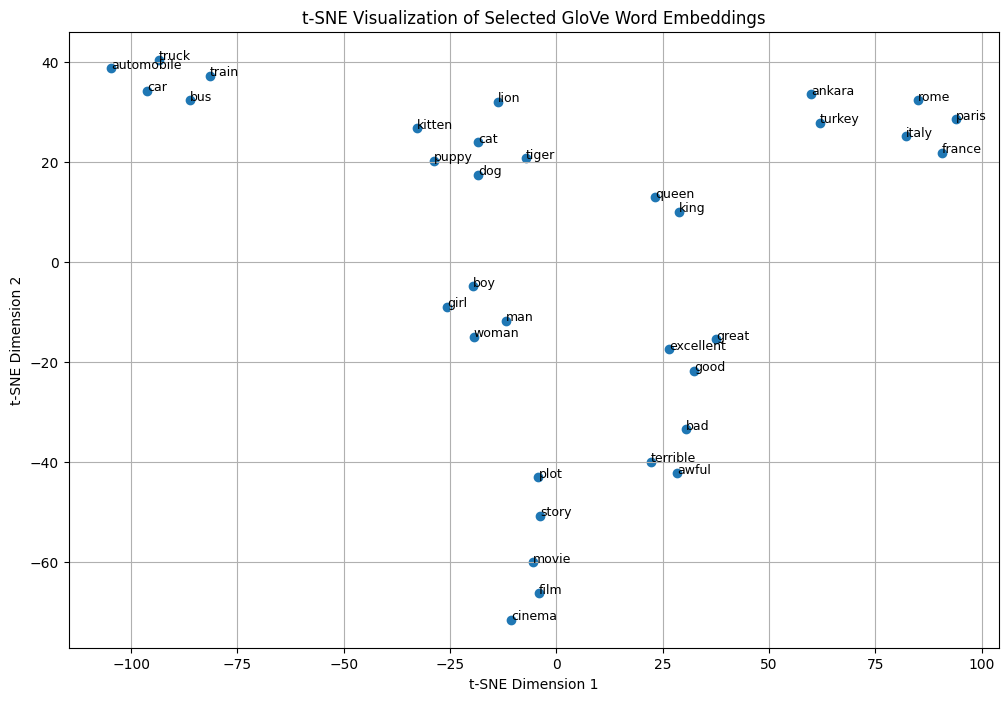

Comment:
Some related words appear near each other, such as country-capital pairs or similar categories like animals and vehicles. This shows that GloVe embeddings can capture semantic similarity between words.


In [6]:
# Cell 1.5 - Visualize Selected Embeddings with t-SNE

words_to_plot = [
    "king", "queen", "man", "woman", "boy", "girl",
    "car", "automobile", "truck", "bus", "train",
    "dog", "cat", "puppy", "kitten", "lion", "tiger",
    "good", "great", "excellent", "bad", "terrible", "awful",
    "movie", "film", "cinema", "story", "plot",
    "france", "paris", "italy", "rome", "turkey", "ankara"
]

# TODO 1: Keep only words that exist in word_to_vec.
valid_words = [word for word in words_to_plot if word in word_to_vec]
# TODO 2: Stack their vectors into a matrix X_embed.
X_embed = np.array([word_to_vec[word] for word in valid_words])
# TODO 3: Use TSNE with n_components=2, perplexity=5, init="pca", random_state=42.
tsne = TSNE(n_components=2, perplexity=5, init="pca", random_state=42)
X_2d = tsne.fit_transform(X_embed)
# TODO 4: Create a scatter plot and label each point with its word.
plt.figure(figsize=(12, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1])
# TODO 5: Add title, x-label, y-label, and grid.
for i, word in enumerate(valid_words):
    plt.annotate(word, (X_2d[i, 0], X_2d[i, 1]), fontsize=9)

plt.title("t-SNE Visualization of Selected GloVe Word Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.show()

print("Comment:")
print("Some related words appear near each other, such as country-capital pairs or similar categories like animals and vehicles. This shows that GloVe embeddings can capture semantic similarity between words.")

# Question 2 - Sentiment Classification with Multinomial Naive Bayes

**50 points total**

In this question, you will download the UCI Sentiment Labelled Sentences dataset, preprocess the text, create Bag-of-Words features, train a Multinomial Naive Bayes classifier, and evaluate the classifier.

You must use `MultinomialNB(alpha=1.0)` for the classifier.

## Cell 2.1 - Download, Load, and Inspect the Dataset

**10 points**

**Goal:** Download the UCI sentiment dataset, combine Amazon, IMDb, and Yelp sentences into one DataFrame, and inspect the dataset.

In [7]:
# Cell 2.1 - Download, Load, and Inspect the Dataset

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

uci_url = "https://archive.ics.uci.edu/static/public/331/sentiment%2Blabelled%2Bsentences.zip"
zip_path = DATA_DIR / "sentiment_labelled_sentences.zip"
combined_csv_path = DATA_DIR / "sentiment_reviews_uci.csv"

# TODO 1: Download the zip file from uci_url if it does not already exist.
# Hint: use Request, urlopen, and zip_path.write_bytes(...).
if not zip_path.exists():
    request = Request(uci_url, headers={"User-Agent": "Mozilla/5.0"})
    with urlopen(request) as response:
        zip_path.write_bytes(response.read())

print("Zip file path:", zip_path)


def find_file_in_zip(zip_file, filename_suffix):
    """Find a file inside a zip archive by suffix."""
    # TODO: Return the first filename in zip_file.namelist() that ends with filename_suffix.
    for filename in zip_file.namelist():
      if filename.endswith(filename_suffix):
          return filename
    # If no match exists, raise FileNotFoundError.
    raise FileNotFoundError(f"No file ending with {filename_suffix} found in zip archive.")
    pass


# TODO 2: Open the zip file using zipfile.ZipFile.
# TODO 3: Read amazon_cells_labelled.txt, imdb_labelled.txt, and yelp_labelled.txt.
# TODO 4: Add a source column for each dataset.
dfs = []

with zipfile.ZipFile(zip_path, "r") as z:
    files_and_sources = [
        ("amazon_cells_labelled.txt", "Amazon"),
        ("imdb_labelled.txt", "IMDb"),
        ("yelp_labelled.txt", "Yelp"),
    ]

    for filename_suffix, source in files_and_sources:
        file_in_zip = find_file_in_zip(z, filename_suffix)

        df_part = pd.read_csv(
            z.open(file_in_zip),
            sep="\t",
            header=None,
            names=["text", "label"]
        )

        df_part["source"] = source
        dfs.append(df_part)

# TODO 5: Concatenate the three DataFrames into sentiment_df.
sentiment_df = pd.concat(dfs, ignore_index=True)
# TODO 6: Create label_name where 0 -> "negative" and 1 -> "positive".
sentiment_df["label_name"] = sentiment_df["label"].map({
    0: "negative",
    1: "positive"
})
# TODO 7: Save the combined DataFrame to combined_csv_path.
sentiment_df.to_csv(combined_csv_path, index=False)
# TODO 8: Display the first 5 rows, shape, class distribution, source distribution,
#         one positive example, and one negative example.
print("First 5 rows:")
display(sentiment_df.head())

print("\nDataFrame shape:")
print(sentiment_df.shape)

print("\nClass distribution:")
print(sentiment_df["label_name"].value_counts())

print("\nSource distribution:")
print(sentiment_df["source"].value_counts())

print("\nOne positive example:")
print(sentiment_df[sentiment_df["label"] == 1]["text"].iloc[0])

print("\nOne negative example:")
print(sentiment_df[sentiment_df["label"] == 0]["text"].iloc[0])

Zip file path: data/sentiment_labelled_sentences.zip
First 5 rows:


,text,label,source,label_name
0,So there is no way for me to plug it in here i...,0,Amazon,negative
1,"Good case, Excellent value.",1,Amazon,positive
2,Great for the jawbone.,1,Amazon,positive
3,Tied to charger for conversations lasting more...,0,Amazon,negative
4,The mic is great.,1,Amazon,positive



DataFrame shape:
(2748, 4)

Class distribution:
label_name
positive    1386
negative    1362
Name: count, dtype: int64

Source distribution:
source
Amazon    1000
Yelp      1000
IMDb       748
Name: count, dtype: int64

One positive example:
Good case, Excellent value.

One negative example:
So there is no way for me to plug it in here in the US unless I go by a converter.


## Cell 2.2 - Basic Text Preprocessing

**10 points**

**Goal:** Clean the review text by lowercasing, handling common negation contractions, removing punctuation, and removing extra spaces while keeping negation words.

In [8]:
# Cell 2.2 - Basic Text Preprocessing

def preprocess_text(text):
    """
    Basic preprocessing for sentiment classification.

    Important:
    Keep negation words such as 'not', 'no', and 'never' because they are important for sentiment.
    """
    # TODO: Convert text to string and lowercase it.
    text = str(text).lower()
    # TODO: Expand common negation contractions such as can't -> can not and won't -> will not.
    text = re.sub(r"can't", "can not", text)
    text = re.sub(r"cannot", "can not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"n't", " not", text)
    # TODO: Replace punctuation / non-alphanumeric characters with spaces.
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    # TODO: Remove extra spaces.
    text = re.sub(r"\s+", " ", text).strip()
    # TODO: Return the cleaned text.
    return text
    pass


# TODO: Apply preprocess_text to sentiment_df["text"] and create sentiment_df["clean_text"].
sentiment_df["clean_text"] = sentiment_df["text"].apply(preprocess_text)
# TODO: Print several original vs. cleaned examples.
print("Original vs. cleaned examples:")
for i in range(5):
    print("\nOriginal:", sentiment_df["text"].iloc[i])
    print("Cleaned :", sentiment_df["clean_text"].iloc[i])

# TODO: Display examples containing negation words such as not, no, or never, if present.
negation_examples = sentiment_df[
    sentiment_df["clean_text"].str.contains(r"\b(?:not|no|never)\b", regex=True)
]

print("\nExamples containing negation words:")
display(negation_examples[["text", "clean_text", "label_name"]].head())

Original vs. cleaned examples:

Original: So there is no way for me to plug it in here in the US unless I go by a converter.
Cleaned : so there is no way for me to plug it in here in the us unless i go by a converter

Original: Good case, Excellent value.
Cleaned : good case excellent value

Original: Great for the jawbone.
Cleaned : great for the jawbone

Original: Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!
Cleaned : tied to charger for conversations lasting more than 45 minutes major problems

Original: The mic is great.
Cleaned : the mic is great

Examples containing negation words:


,text,clean_text,label_name
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...,negative
14,"The design is very odd, as the ear ""clip"" is n...",the design is very odd as the ear clip is not ...,negative
16,I advise EVERYONE DO NOT BE FOOLED!,i advise everyone do not be fooled,negative
20,I went on Motorola's website and followed all ...,i went on motorola s website and followed all ...,negative
27,I didn't think that the instructions provided ...,i did not think that the instructions provided...,negative


## Cell 2.3 - Train/Test Split and Bag-of-Words Features

**10 points**

**Goal:** Split the cleaned text into training and test sets, then create unigram and bigram Bag-of-Words features using `CountVectorizer`.

In [9]:
# Cell 2.3 - Train/Test Split and Bag-of-Words Features

# TODO 1: Set X_text to the cleaned text column and y to the label_name column.
X_text = sentiment_df["clean_text"]
y = sentiment_df["label_name"]
# TODO 2: Use train_test_split with:
#         test_size=0.2, random_state=42, stratify=y
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# TODO 3: Create CountVectorizer with ngram_range=(1, 2) and min_df=2.
vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2)
# TODO 4: Fit the vectorizer only on the training text.
X_train_counts = vectorizer.fit_transform(X_train_text)
# TODO 5: Transform both the training and test text.
X_test_counts = vectorizer.transform(X_test_text)
# TODO 6: Print the number of training examples, number of test examples,
#         number of features, matrix shapes, and first 20 feature names.
feature_names = vectorizer.get_feature_names_out()

print("Number of training examples:", X_train_counts.shape[0])
print("Number of test examples:", X_test_counts.shape[0])
print("Number of features:", X_train_counts.shape[1])

print("\nTraining matrix shape:", X_train_counts.shape)
print("Test matrix shape:", X_test_counts.shape)

print("\nFirst 20 feature names:")
print(feature_names[:20])

Number of training examples: 2198
Number of test examples: 550
Number of features: 4422

Training matrix shape: (2198, 4422)
Test matrix shape: (550, 4422)

First 20 feature names:
['10' '10 10' '10 minutes' '10 out' '100' '11' '12' '15' '15 minutes' '20'
 '20 minutes' '2005' '20th' '25' '25 years' '30' '30 minutes' '40'
 '40 minutes' '50']


## Cell 2.4 - Train Multinomial Naive Bayes and Inspect Important Tokens

**10 points**

**Goal:** Train `MultinomialNB(alpha=1.0)` and inspect the most predictive positive and negative words/bigrams.

In [10]:
# Cell 2.4 - Train Multinomial Naive Bayes and Inspect Important Tokens

# TODO 1: Initialize MultinomialNB(alpha=1.0).
nb_model = MultinomialNB(alpha=1.0)
# TODO 2: Fit the classifier on the training Bag-of-Words matrix.
nb_model.fit(X_train_counts, y_train)
# TODO 3: Print the model classes.
print("Model classes:", nb_model.classes_)
# TODO 4: Extract feature names from the vectorizer.
feature_names = vectorizer.get_feature_names_out()
# TODO 5: Use clf.feature_log_prob_ to find the strongest positive and negative features.
negative_class_index = list(nb_model.classes_).index("negative")
positive_class_index = list(nb_model.classes_).index("positive")

negative_log_probs = nb_model.feature_log_prob_[negative_class_index]
positive_log_probs = nb_model.feature_log_prob_[positive_class_index]

log_prob_diff = positive_log_probs - negative_log_probs

top_positive_indices = np.argsort(log_prob_diff)[-20:][::-1]
top_negative_indices = np.argsort(log_prob_diff)[:20]

top_positive_features = pd.DataFrame({
    "feature": feature_names[top_positive_indices],
    "score": log_prob_diff[top_positive_indices]
})

top_negative_features = pd.DataFrame({
    "feature": feature_names[top_negative_indices],
    "score": log_prob_diff[top_negative_indices]
})
# TODO 6: Display the top positive and top negative features in clear tables.
print("\nTop positive words/bigrams:")
display(top_positive_features)

print("\nTop negative words/bigrams:")
display(top_negative_features)

Model classes: ['negative' 'positive']

Top positive words/bigrams:


,feature,score
0,very good,3.158628
1,delicious,2.967573
2,fantastic,2.731184
3,interesting,2.662191
4,works great,2.508041
5,perfect,2.508041
6,so far,2.508041
7,great,2.446672
8,love the,2.421029
9,family,2.421029



Top negative words/bigrams:


,feature,score
0,the worst,-3.154920
1,poor,-3.154920
2,worst,-2.780226
3,not good,-2.684916
4,waste,-2.541815
5,bland,-2.541815
6,waste your,-2.541815
7,sucked,-2.461773
8,money,-2.461773
9,disappointing,-2.374761


## Cell 2.5 - Evaluate and Interpret the Classifier

**10 points**

**Goal:** Evaluate the Naive Bayes classifier using accuracy, confusion matrix, classification report, and misclassified examples.

Test accuracy: 0.8218

Classification report:
              precision    recall  f1-score   support

    negative       0.80      0.85      0.82       273
    positive       0.84      0.80      0.82       277

    accuracy                           0.82       550
   macro avg       0.82      0.82      0.82       550
weighted avg       0.82      0.82      0.82       550



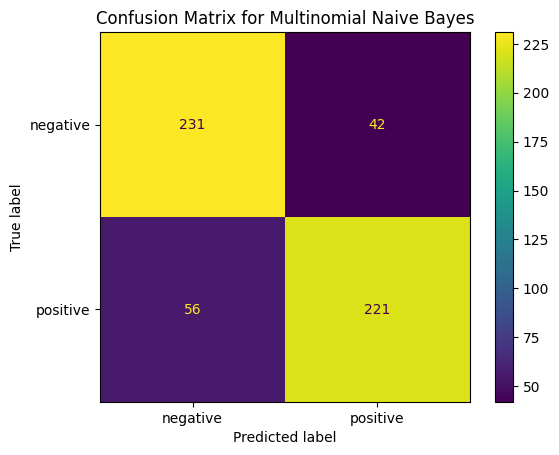


Misclassified examples:


,text,true_label,predicted_label
0,very unreliable service from t mobile,negative,positive
8,the portion was huge,positive,negative
13,food was so gooodd,positive,negative



Comment:
Some errors may happen because short reviews do not give enough context, or because words can have different meanings depending on the sentence.


In [11]:
# Cell 2.5 - Evaluate and Interpret the Classifier

# TODO 1: Predict labels for the test set.
y_pred = nb_model.predict(X_test_counts)
# TODO 2: Compute and print test accuracy.
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", round(accuracy, 4))
# TODO 3: Print the classification report.
print("\nClassification report:")
print(classification_report(y_test, y_pred))
# TODO 4: Plot the confusion matrix.
cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_model.classes_
)

disp.plot()
plt.title("Confusion Matrix for Multinomial Naive Bayes")
plt.show()

# TODO 5: Create a DataFrame with text, true_label, and predicted_label.
results_df = pd.DataFrame({
    "text": X_test_text.values,
    "true_label": y_test.values,
    "predicted_label": y_pred
})
# TODO 6: Display up to 3 misclassified examples.
misclassified = results_df[results_df["true_label"] != results_df["predicted_label"]]

print("\nMisclassified examples:")
display(misclassified.head(3))
# TODO 7: Print a short interpretation explaining one possible source of error.
print("\nComment:")
print("Some errors may happen because short reviews do not give enough context, or because words can have different meanings depending on the sentence.")